In [1]:
import torch
from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import (
    HydrAMPEncoderDecoder,
)
from pep_compass.models.encoder_decoder.utils import decoder_jacobian
from pep_compass.local_enumeration.mutation.utils import get_mutations_from_s_u_standard
from pep_compass.local_enumeration.sampling.sorbes import SubRiemannianTangentSpace

from pep_compass.local_enumeration.mutation.mutation_potentials import (
    compose_mutant_distribution,
    ProjectedDirectionPairwiseSimilarityPotential,
    DecoderLogProbPotential
)

In [2]:
device = torch.device("cpu")
hydramp = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=1e-6,
    field_eps=1e-6,
    device=device,
)
peps = ["FLYKWWIRIGRLKL", "KYCRRFRWLTFRWL", "KFRNRHRWKFKLIFRN", "KKYWLIRKWIRLWFLT", "KTLKIIRLLF", "RMARNLVRYVQGLKKKKVI"]

In [3]:
peptide = peps[0]
pep_len = len(peptide)
z = hydramp.encode_peptides([peptide])
print(f"Parent: {peptide}")
print(f"Latent shape: {z.shape}")

Parent: FLYKWWIRIGRLKL
Latent shape: torch.Size([1, 64])


In [4]:
jac = decoder_jacobian(
    lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
    z,
    jacobian_fn_mode="approx",
    jacobian_fn_kwargs={"jacobian_eps": 1e-6},
)
U, S, V = torch.linalg.svd(jac, full_matrices=False)
print(f"U shape: {U.shape}, S shape: {S.shape}, V shape: {V.shape}")

mutations = get_mutations_from_s_u_standard(
    s=S[0].detach().cpu().numpy(),
    u=U[0].detach().cpu().numpy(),
    max_len=25,
    alphabet_size=21,
    direction_significance_threshold=1e-6,
    min_number_of_directions=5,
    token_threshold=1e-4,
)

alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

##take only positions od pep_len
mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
print("\nProposed mutations (only positions within peptide length):")
for pos in sorted(mutations.keys()):
    aas = [alphabet[i] for i in mutations[pos]]
    print(f"  pos {pos}: indices {mutations[pos]}  ->  {aas}")

U shape: torch.Size([1, 525, 64]), S shape: torch.Size([1, 64]), V shape: torch.Size([1, 64, 64])

Proposed mutations (only positions within peptide length):
  pos 0: indices [8, 13, 15, 20, 2, 7, 8, 13, 15, 18, 20]  ->  ['I', 'P', 'R', 'Y', 'C', 'H', 'I', 'P', 'R', 'V', 'Y']
  pos 2: indices [5, 14, 15, 5, 14, 15]  ->  ['F', 'Q', 'R', 'F', 'Q', 'R']
  pos 3: indices [14, 19, 14, 19]  ->  ['Q', 'W', 'Q', 'W']
  pos 6: indices [5, 7, 13, 17, 5, 7, 13, 17, 5, 7, 10, 13, 17]  ->  ['F', 'H', 'P', 'T', 'F', 'H', 'P', 'T', 'F', 'H', 'L', 'P', 'T']
  pos 8: indices [5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17]  ->  ['F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T']
  pos 11: indices [4, 8, 9, 12, 17, 4, 8, 9, 12, 17]  ->  ['E', 

In [5]:
# Create tangent space for the peptide
tangent_space = SubRiemannianTangentSpace(
    U=U[0], 
    S=S[0], 
    V=V[0],
    horizontal_threshold=1e-4, 
    device="cpu"
)

# Create potential using the new class
potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)
potentials_dict = potential.compute_with_identities(peptide, mutations)
sequences, scores = potential.return_list_abovethreshold(
    parent_peptide=peptide,
    potentials=potentials_dict,
    mutations=mutations,
    threshold=-2  # optional, default is -0.5
)
print(len(sequences))




48383


In [6]:
potential_normal = DecoderLogProbPotential(encoder_decoder=hydramp)

##print len of potential_normal
print(potential_normal.compute(peptide, mutations))
df = compose_mutant_distribution(
    parent_peptide=peptide,
    mutations=mutations,
    potential=potential_normal,
    include_parent_residue=True,
    top_k=50000,
)

df

{12: {19: -11.011273384094238}, 6: {5: -12.974300384521484, 7: -14.771862030029297, 13: -12.583324432373047, 17: -16.235382080078125, 10: -21.113801956176758}, 0: {8: -16.98579216003418, 13: -16.823253631591797, 15: -14.999544143676758, 20: -10.881237030029297, 2: -21.002368927001953, 7: -18.047252655029297, 18: -19.594608306884766}, 3: {14: -16.130268096923828, 19: -12.352595329284668}, 8: {5: -15.116011619567871, 7: -16.42665672302246, 10: -16.7426815032959, 12: -18.30915641784668, 13: -13.454051971435547, 17: -15.956916809082031}, 2: {5: -16.84764862060547, 14: -20.3785457611084, 15: -15.771146774291992}, 11: {4: -18.077594757080078, 8: -19.071876525878906, 9: -23.688352584838867, 12: -16.195301055908203, 17: -19.30636978149414}}


MutantDistribution(sequences=['FLYKWWIRIGRLKL', 'YLYKWWIRIGRLKL', 'FLYKWWIRIGRLWL', 'FLYWWWIRIGRLKL', 'FLYKWWPRIGRLKL', 'FLYKWWFRIGRLKL', 'FLYKWWIRPGRLKL', 'FLYKWWHRIGRLKL', 'RLYKWWIRIGRLKL', 'FLYKWWIRFGRLKL', 'FLRKWWIRIGRLKL', 'FLYKWWIRTGRLKL', 'FLYQWWIRIGRLKL', 'FLYKWWIRIGRNKL', 'FLYKWWTRIGRLKL', 'FLYKWWIRHGRLKL', 'FLYKWWIRLGRLKL', 'PLYKWWIRIGRLKL', 'FLFKWWIRIGRLKL', 'ILYKWWIRIGRLKL', 'HLYKWWIRIGRLKL', 'FLYKWWIRIGREKL', 'FLYKWWIRNGRLKL', 'FLYKWWIRIGRIKL', 'FLYKWWIRIGRTKL', 'VLYKWWIRIGRLKL', 'FLQKWWIRIGRLKL', 'CLYKWWIRIGRLKL', 'FLYKWWLRIGRLKL', 'YLYKWWIRIGRLWL', 'YLYWWWIRIGRLKL', 'FLYWWWIRIGRLWL', 'YLYKWWPRIGRLKL', 'FLYKWWPRIGRLWL', 'FLYKWWIRIGRKKL', 'YLYKWWFRIGRLKL', 'FLYKWWFRIGRLWL', 'YLYKWWIRPGRLKL', 'FLYKWWIRPGRLWL', 'FLYWWWPRIGRLKL', 'FLYWWWFRIGRLKL', 'YLYKWWHRIGRLKL', 'FLYKWWHRIGRLWL', 'FLYWWWIRPGRLKL', 'YLYKWWIRFGRLKL', 'RLYKWWIRIGRLWL', 'FLYKWWPRPGRLKL', 'FLYKWWIRFGRLWL', 'FLYKWWFRPGRLKL', 'YLRKWWIRIGRLKL', 'FLRKWWIRIGRLWL', 'YLYKWWIRTGRLKL', 'FLYKWWIRTGRLWL', 'YLYQWWIRIGRLKL'

In [7]:
import numpy as np

## Compare sequences and scores for different values of n
# sequences, scores: from return_list_abovethreshold (pairwise similarity potential)
# df: from compose_mutant_distribution (decoder log prob potential)

print("Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential\n")

# Extract sequences and scores from df (MutantDistribution namedtuple)
if hasattr(df, 'sequences') and hasattr(df, 'log_potentials'):
    # It's a MutantDistribution namedtuple
    df_sequences = list(df.sequences)
    df_scores = list(df.log_potentials) if isinstance(df.log_potentials, np.ndarray) else list(df.log_potentials)
else:
    # It's a DataFrame or dict
    if isinstance(df, dict):
        df_sequences = list(df.keys())
        df_scores = list(df.values())
    else:
        peptide_col = 'sequences' if 'sequences' in df.columns else ('peptide' if 'peptide' in df.columns else df.columns[0])
        score_col = 'log_potentials' if 'log_potentials' in df.columns else ('score' if 'score' in df.columns else df.columns[1])
        df_sequences = df[peptide_col].tolist()
        df_scores = df[score_col].tolist()

print(f"Data loaded:")
print(f"  Pairwise similarity: {len(sequences)} sequences")
print(f"  Decoder log prob: {len(df_sequences)} sequences")

# Create dictionaries for easy lookup
seq_scores_dict = {sequences[i]: scores[i] for i in range(len(sequences))}
df_scores_dict = {df_sequences[i]: df_scores[i] for i in range(len(df_sequences))}

# Simple correlation functions (Pearson only, no scipy needed)
def pearson_correlation(x, y):
    """Compute Pearson correlation coefficient."""
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    if n < 2:
        return np.nan
    
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    cov = np.sum((x - mean_x) * (y - mean_y))
    std_x = np.sqrt(np.sum((x - mean_x)**2))
    std_y = np.sqrt(np.sum((y - mean_y)**2))
    
    if std_x == 0 or std_y == 0:
        return np.nan
    
    return cov / (std_x * std_y)

# Compare for different n values
for n in [50, 100, 500, 1000]:
    # Adjust n if it exceeds available data
    n = min(n, len(sequences), len(df_sequences))
    
    if n < 2:
        continue
    
    # Get top n sequences from both sources
    seq_set_n = set(sequences[:n])
    df_set_n = set(df_sequences[:n])
    
    # Find overlap
    overlap = seq_set_n.intersection(df_set_n)
    
    print(f"\n{'='*60}")
    print(f"Comparison for top n={n}")
    print(f"{'='*60}")
    print(f"Peptides in both sources: {len(overlap)}/{n}")
    print(f"Overlap percentage: {100*len(overlap)/n:.1f}%")
    print(f"Only in pairwise similarity: {len(seq_set_n - df_set_n)}")
    print(f"Only in decoder log prob: {len(df_set_n - seq_set_n)}")
    
    # Show some examples
    if len(overlap) > 0:
        print(f"\nExample overlapping sequences (first 5):")
        for i, seq in enumerate(list(overlap)[:5]):
            print(f"  {seq}: pairwise={seq_scores_dict[seq]:.3f}, logprob={df_scores_dict[seq]:.3f}")
    
    # For overlapping sequences, compare scores
    if len(overlap) >= 2:
        # Get scores from both sources for overlapping sequences
        overlap_pairwise_scores = [seq_scores_dict[seq] for seq in overlap if seq in seq_scores_dict]
        overlap_logprob_scores = [df_scores_dict[seq] for seq in overlap if seq in df_scores_dict]
        
        # Filter out any inf or nan values
        valid_pairs = [(p, l) for p, l in zip(overlap_pairwise_scores, overlap_logprob_scores) 
                       if np.isfinite(p) and np.isfinite(l)]
        
        if len(valid_pairs) >= 2:
            overlap_pairwise_scores = [p for p, l in valid_pairs]
            overlap_logprob_scores = [l for p, l in valid_pairs]
            
            # Compute correlation
            pearson_corr = pearson_correlation(overlap_pairwise_scores, overlap_logprob_scores)
            
            print(f"\nScore correlation for {len(valid_pairs)} overlapping peptides:")
            print(f"  Pearson: {pearson_corr:.4f}")
        else:
            print(f"\nNot enough valid pairs ({len(valid_pairs)}) to compute correlation (need >= 2)")
    else:
        print(f"\nNot enough overlap ({len(overlap)}) to compute correlation")

print(f"\n{'='*60}")
print("Summary: These are two different ranking methods:")
print("  - Pairwise Similarity: Favors mutations that are geometrically aligned")
print("  - Decoder Log Prob: Favors mutations with high decoder probability")
print("They may produce different rankings based on different criteria.")

Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential

Data loaded:
  Pairwise similarity: 48383 sequences
  Decoder log prob: 48384 sequences

Comparison for top n=50
Peptides in both sources: 7/50
Overlap percentage: 14.0%
Only in pairwise similarity: 43
Only in decoder log prob: 43

Example overlapping sequences (first 5):
  FLYKWWIRTGRLKL: pairwise=1.050, logprob=-15.957
  FLRKWWIRIGRLKL: pairwise=0.942, logprob=-15.771
  FLYKWWIRIGREKL: pairwise=1.149, logprob=-18.078
  FLYKWWPRIGRLKL: pairwise=1.216, logprob=-12.583
  FLYKWWIRLGRLKL: pairwise=1.063, logprob=-16.743

Score correlation for 7 overlapping peptides:
  Pearson: 0.0082

Comparison for top n=100
Peptides in both sources: 23/100
Overlap percentage: 23.0%
Only in pairwise similarity: 77
Only in decoder log prob: 77

Example overlapping sequences (first 5):
  FLYKWWIRTGRLKL: pairwise=1.050, logprob=-15.957
  FLYKWWPRIGRLKL: pairwise=1.216, logprob=-12.583
  FLYKWWIRLGRLKL: pairwise=1.063, logprob=-16.743
  F

Total possible mutations (Cartesian product minus identity, deduplicated): 1179647


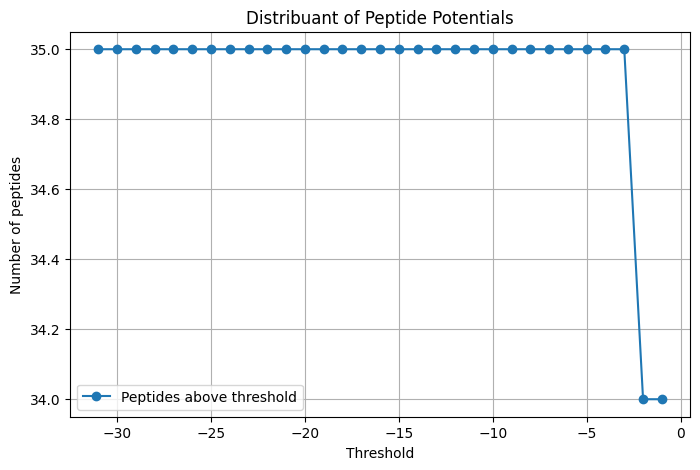

Top 1179647 peptides by similarity score:
  FLYKWWIRHGRLKL: 1.224
  FLYKWWPRIGRLKL: 1.216
  FLYKWWPRIGREKL: 1.160
  FLYKWWPRHGRLKL: 1.160
  FLYKWWIRIGREKL: 1.149
  FLYKWWIRHGREKL: 1.133
  FLYKWWPRHGREKL: 1.097
  FLYKWWIRLGRLKL: 1.063
  FLYKWWPRLGRLKL: 1.060
  FLYKWWPRTGRLKL: 1.052


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- Distribuant function for potentials_dict ---
def plot_potential_distribuant(potentials_dict, thresholds=range(-31, 0)):
    values = np.array(list(potentials_dict.values()))
    counts = [np.sum(values > t) for t in thresholds]
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, counts, marker='o', label='Peptides above threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Number of peptides')
    plt.title('Distribuant of Peptide Potentials')
    plt.grid(True)
    plt.legend()
    plt.show()
    return counts

# --- Mutation count calculation (deduplicate per position) ---
def mutation_count(mutations):
    cleaned = {pos: list(set(muts)) for pos, muts in mutations.items()}
    total = np.prod([len(muts) for muts in cleaned.values()])
    identity = 1  # Only the original sequence
    return total - identity

# --- Use top_k equal to mutation count for logprob potential ---
num_mutations = mutation_count(mutations)
print(f"Total possible mutations (Cartesian product minus identity, deduplicated): {num_mutations}")

# Plot distribuant for potentials_dict
plot_potential_distribuant(potentials_dict, thresholds=range(-31, 0))

# For similarity: show top_k using sequences and scores
if 'sequences' in locals() and 'scores' in locals():
    sorted_indices = np.argsort(scores)[::-1]
    top_sequences = [sequences[i] for i in sorted_indices[:num_mutations]]
    top_scores = [scores[i] for i in sorted_indices[:num_mutations]]
    print(f"Top {num_mutations} peptides by similarity score:")
    for seq, score in zip(top_sequences[:10], top_scores[:10]):
        print(f"  {seq}: {score:.3f}")


Peptide: FLYKWWIRIGRLKL, Total mutations: 191, Potentials computed: 1049
Peptide: KYCRRFRWLTFRWL, Total mutations: 59, Potentials computed: 89
Peptide: KFRNRHRWKFKLIFRN, Total mutations: 5039, Potentials computed: 25199
Peptide: KKYWLIRKWIRLWFLT, Total mutations: 6479, Potentials computed: 71679
Peptide: KTLKIIRLLF, Total mutations: 9, Potentials computed: 35


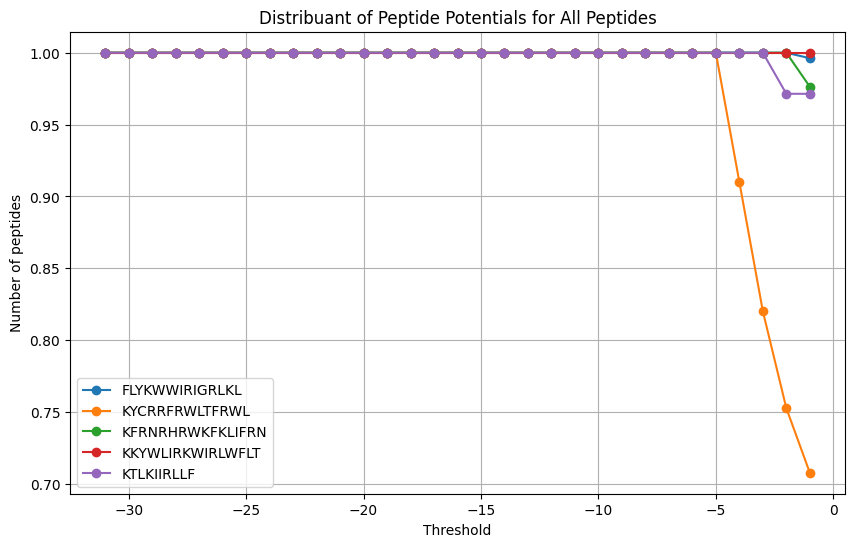

In [9]:
# Plot distribuant curves for all peptides in the peps list
import matplotlib.pyplot as plt
import numpy as np

thresholds = range(-31,0)
plt.figure(figsize=(10, 6))

for pep in peps[:5]:
    pep_len = len(pep)
    z = hydramp.encode_peptides([pep])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=1e-4,
        min_number_of_directions=5,
        token_threshold=1e-4,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
    alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

    tangent_space = SubRiemannianTangentSpace(
        U=U[0], S=S[0], V=V[0], horizontal_threshold=1e-4, device="cpu"
    )
    potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)
    potentials_dict = potential.compute_with_identities(pep, mutations)
    print(f"Peptide: {pep}, Total mutations: {mutation_count(mutations)}, Potentials computed: {len(potentials_dict)}")

    values = np.array(list(potentials_dict.values()))
    counts = [np.sum(values > t)/len(values) for t in thresholds]
    plt.plot(thresholds, counts, marker='o', label=pep)

plt.xlabel('Threshold')
plt.ylabel('Number of peptides')
plt.title('Distribuant of Peptide Potentials for All Peptides')
plt.grid(True)
plt.legend()
plt.show()


Peptide: FLYKWWIRIGRLKL, Total mutations: 719, Mutants computed: 2646
Peptide: KYCRRFRWLTFRWL, Total mutations: 19, Mutants computed: 24
Peptide: KFRNRHRWKFKLIFRN, Total mutations: 4799, Mutants computed: 12500
Peptide: KKYWLIRKWIRLWFLT, Total mutations: 719, Mutants computed: 2520
Peptide: KTLKIIRLLF, Total mutations: 139, Mutants computed: 480


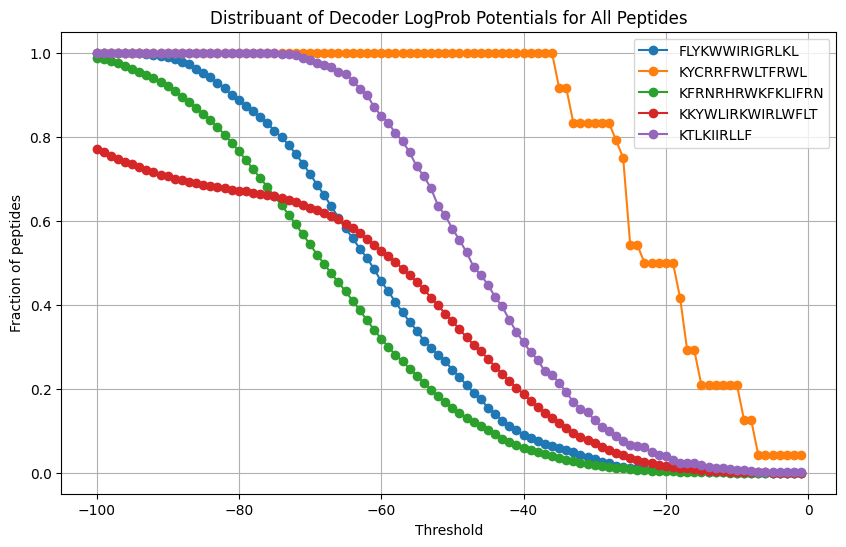

In [10]:
# Plot distribuant curves for all peptides in the peps list using DecoderLogProbPotential
import matplotlib.pyplot as plt
import numpy as np

thresholds = range(-100, 0)
plt.figure(figsize=(10, 6))

for pep in peps[:5]:
    pep_len = len(pep)
    z = hydramp.encode_peptides([pep])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=5e-4,
        min_number_of_directions=7,
        token_threshold=1e-5,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
    alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

    potential_logprob = DecoderLogProbPotential(encoder_decoder=hydramp)
    df = compose_mutant_distribution(
        parent_peptide=pep,
        mutations=mutations,
        potential=potential_logprob,
        include_parent_residue=True,
        top_k=None,
    )
    print(f"Peptide: {pep}, Total mutations: {mutation_count(mutations)}, Mutants computed: {len(df.sequences)}")

    values = np.array(df.log_potentials)
    counts = [np.sum(values > t)/len(values) for t in thresholds]
    plt.plot(thresholds, counts, marker='o', label=pep)

plt.xlabel('Threshold')
plt.ylabel('Fraction of peptides')
plt.title('Distribuant of Decoder LogProb Potentials for All Peptides')
plt.grid(True)
plt.legend()
plt.show()


Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_FLYKWWIRIGRLKL_nmut21.pkl


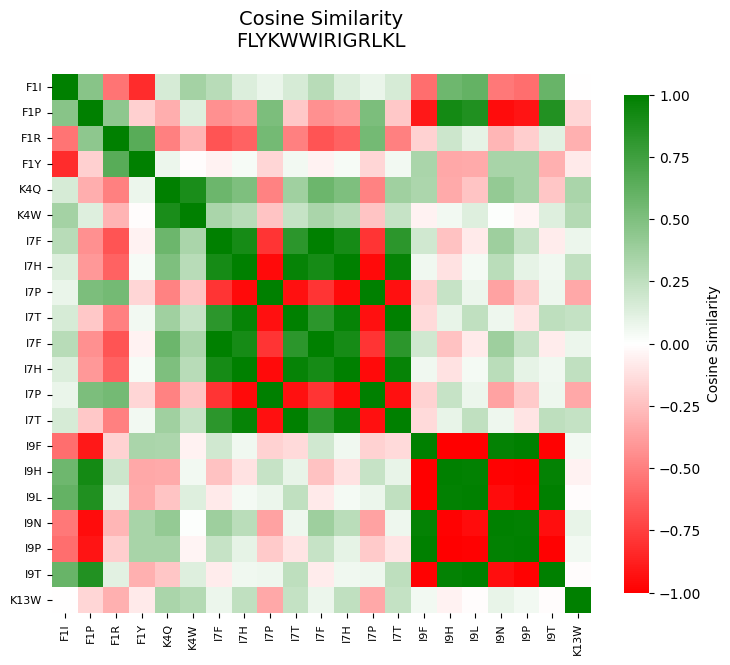

Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_KYCRRFRWLTFRWL_nmut25.pkl


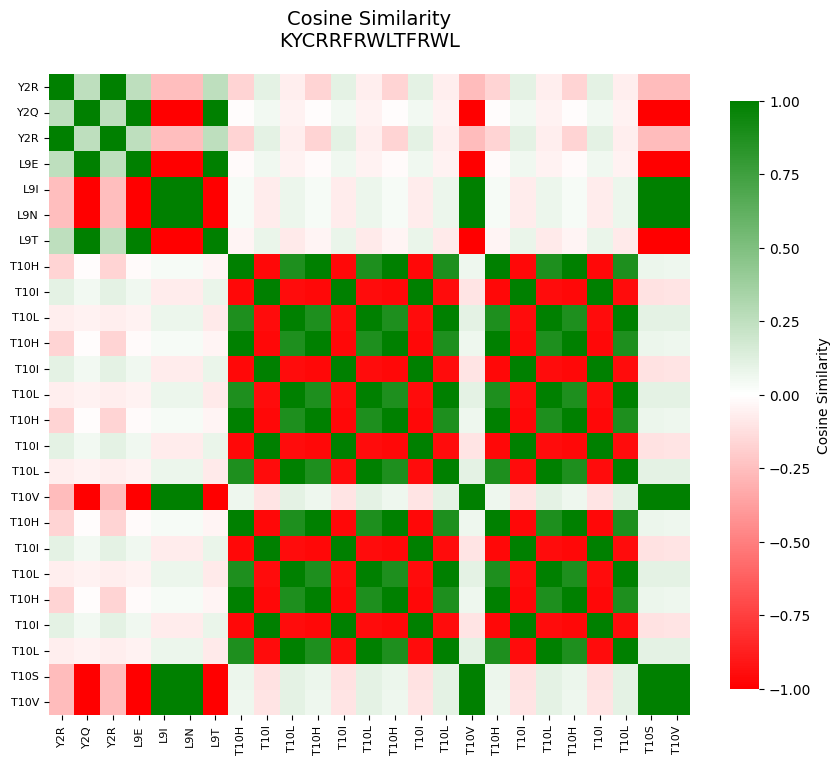

Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_KFRNRHRWKFKLIFRN_nmut35.pkl


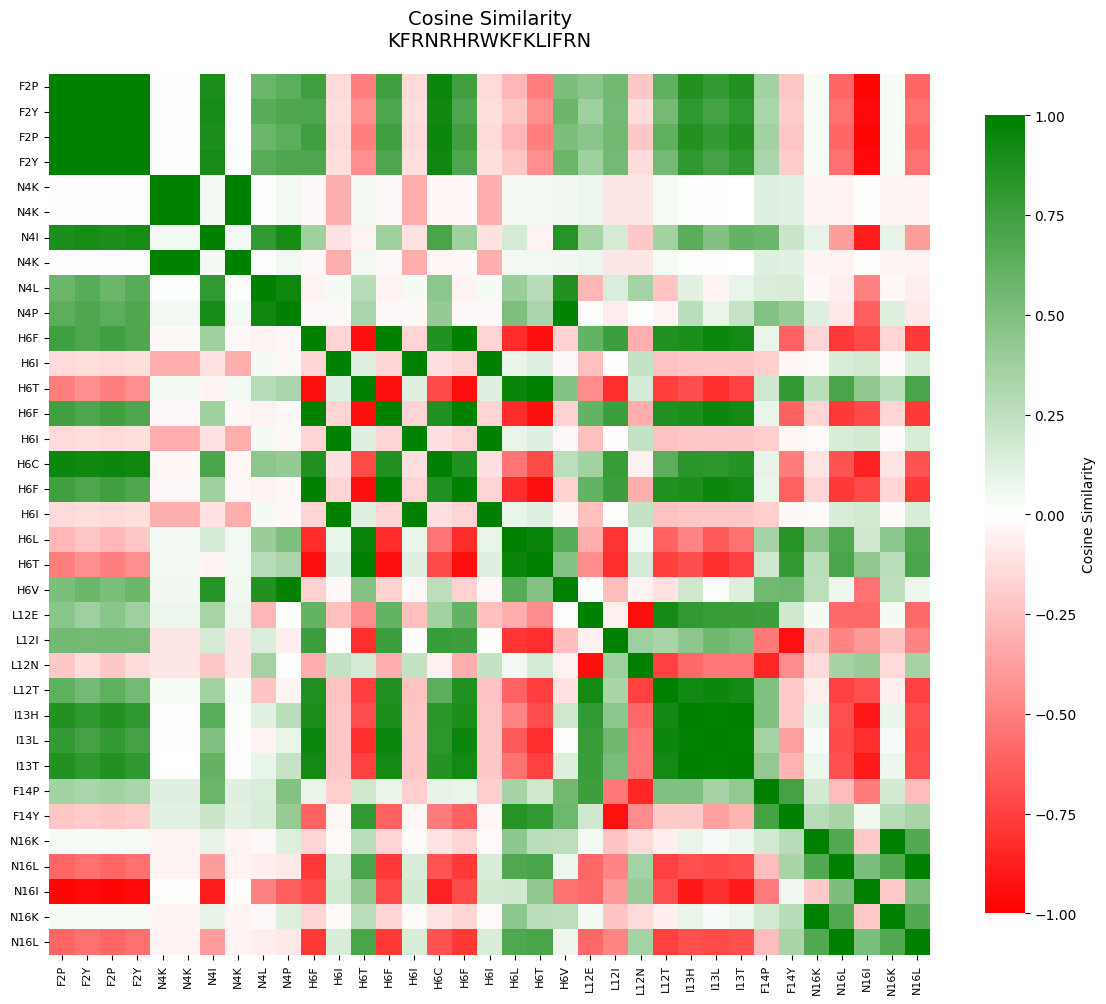

Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_KKYWLIRKWIRLWFLT_nmut40.pkl


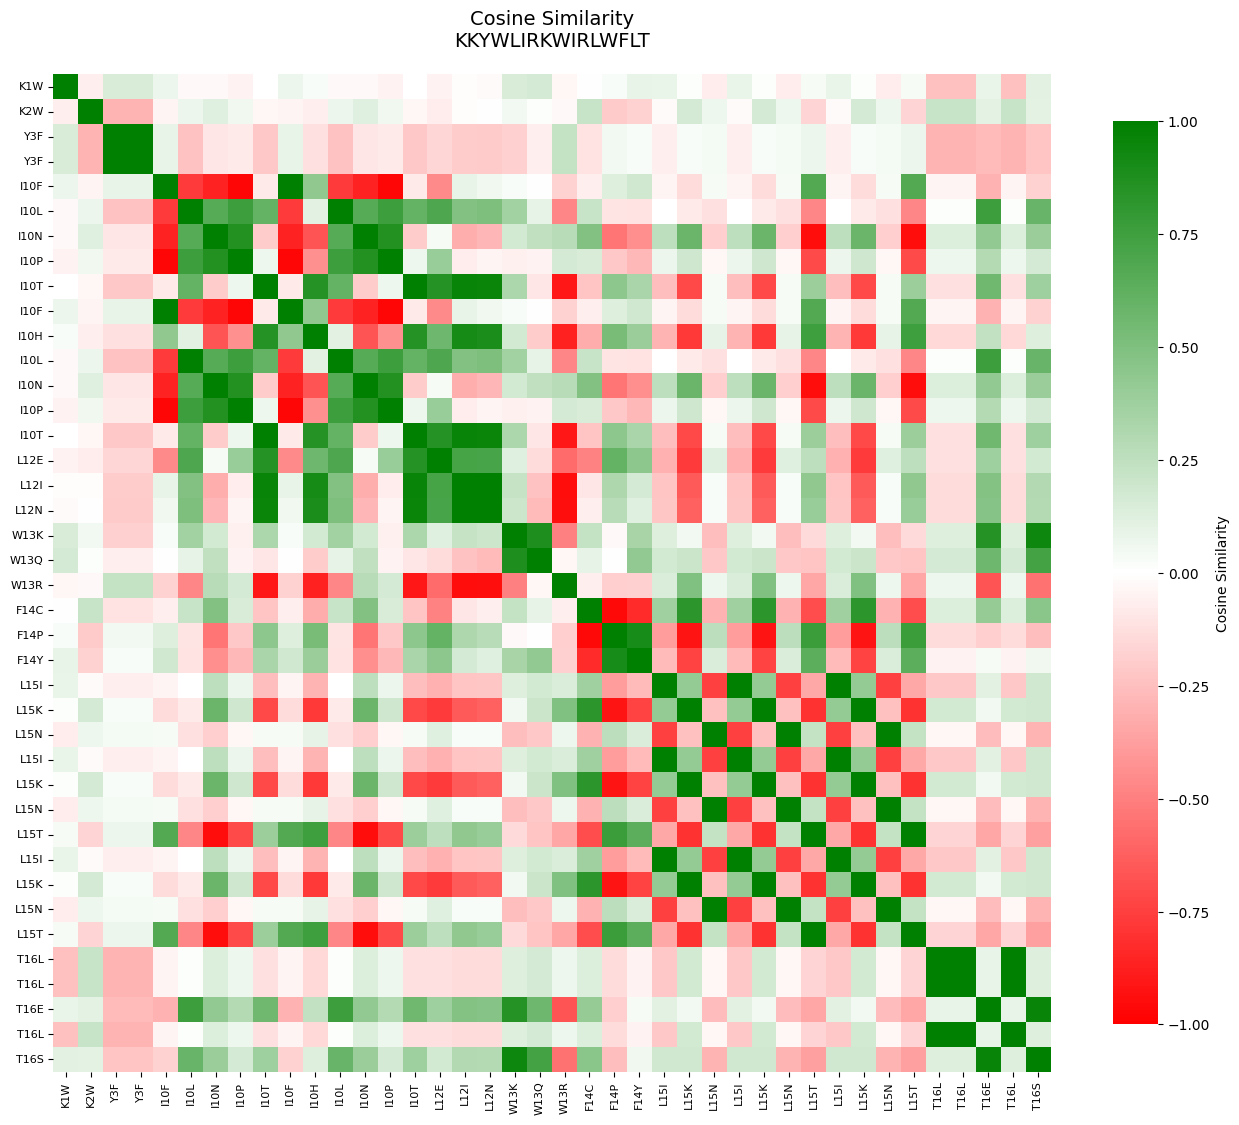

Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_KTLKIIRLLF_nmut18.pkl


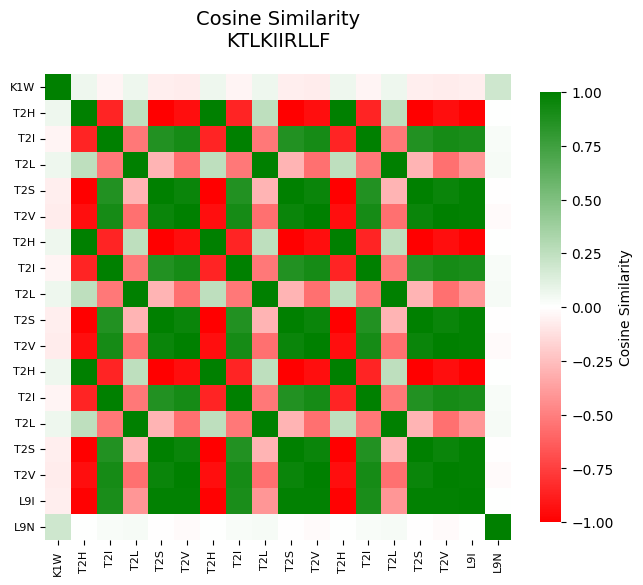

Saved similarity DataFrame to: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_RMARNLVRYVQGLKKKKVI_nmut54.pkl


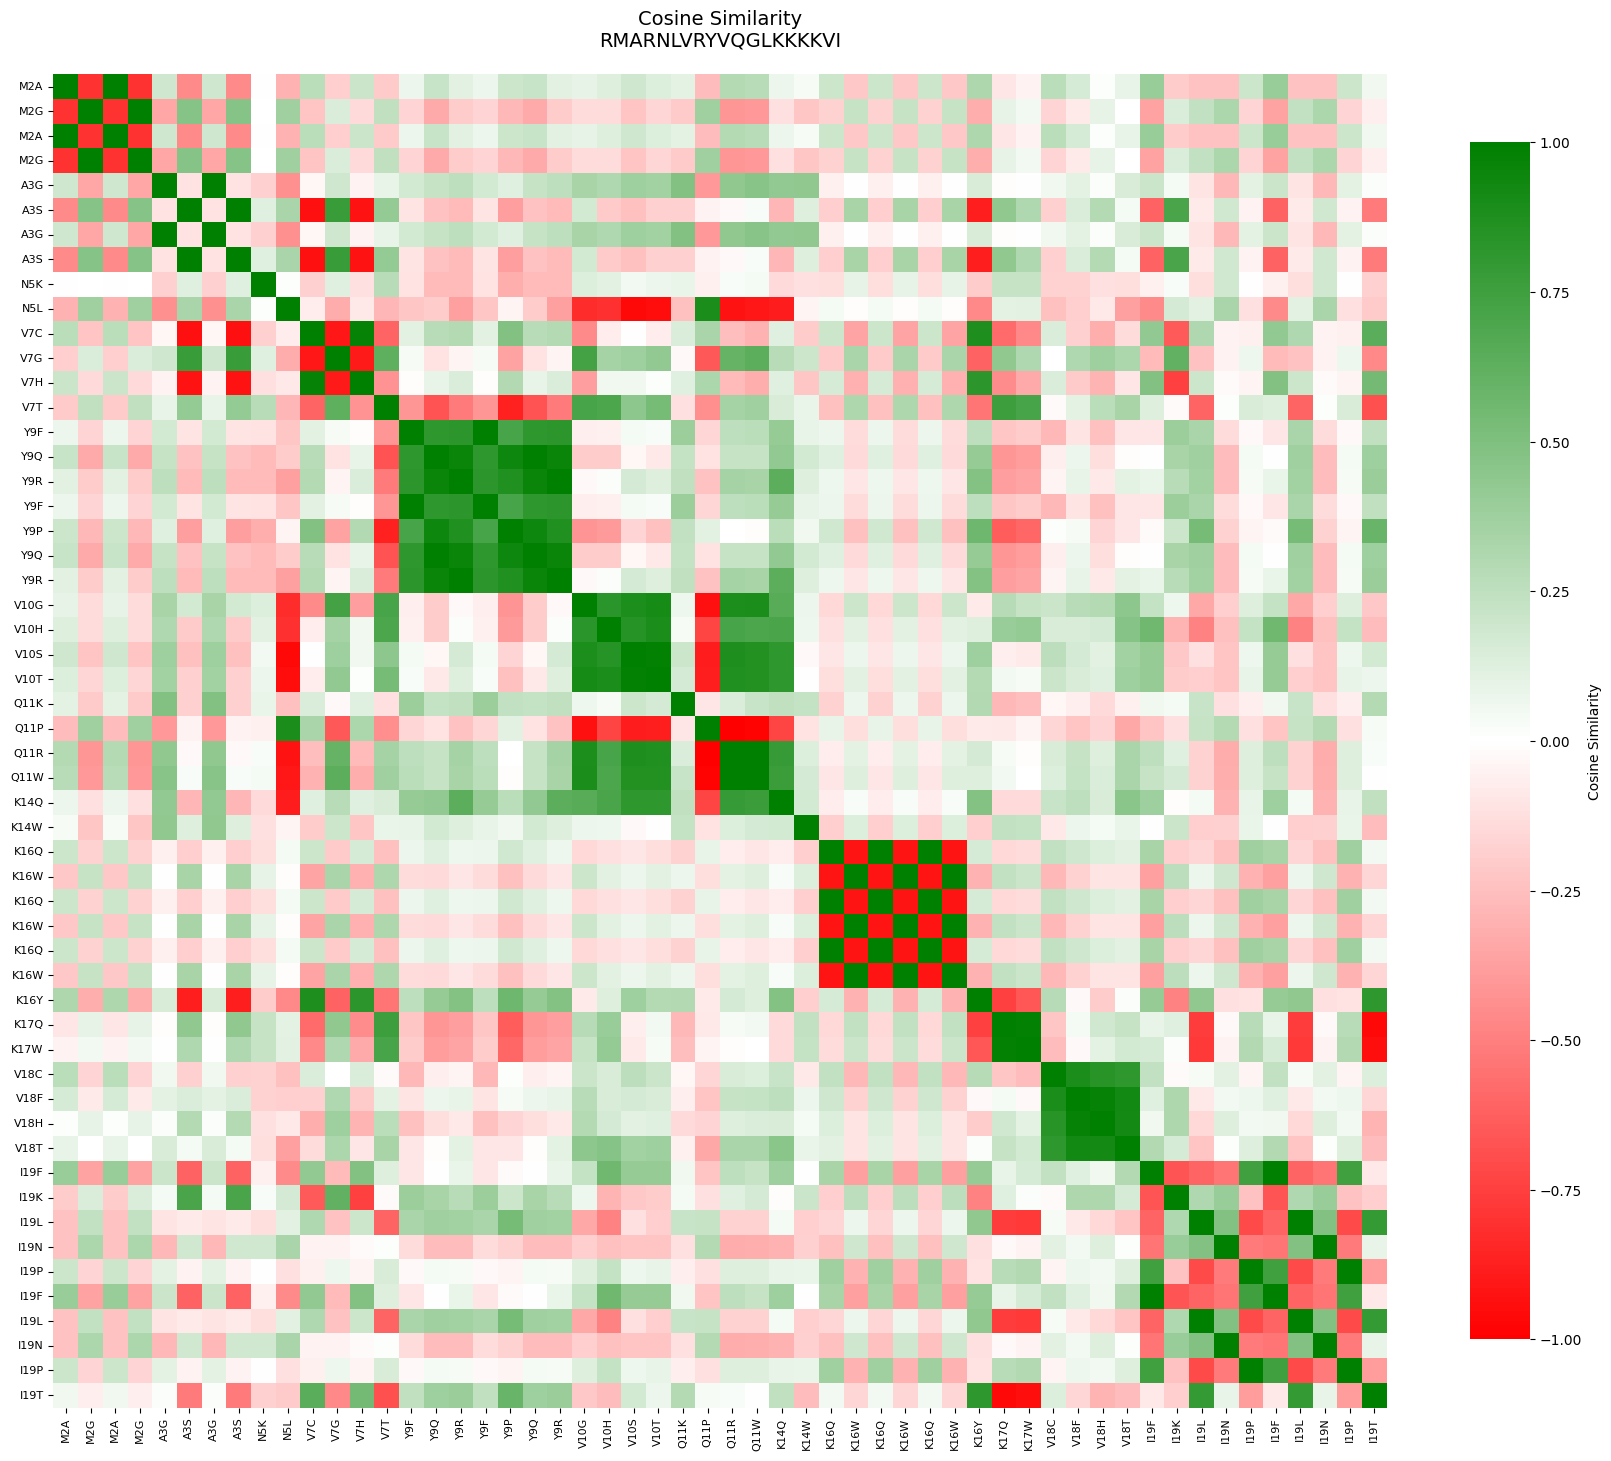

In [11]:
# Elegant mutation-mutation similarity matrices for all peptides (seaborn, green=1, red=-1, smooth)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Custom green-white-red colormap for seaborn
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import os
cmap = LinearSegmentedColormap.from_list("gwr", [(0, "red"), (0.5, "white"), (1, "green")], N=256)

# Directory to save DataFrames as .pkl
save_dir = r"C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes"
os.makedirs(save_dir, exist_ok=True)

for pep in peps:
    pep_len = len(pep)
    z = hydramp.encode_peptides([pep])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    U, S, V = torch.linalg.svd(jac, full_matrices=False)
    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=1e-4,
        min_number_of_directions=5,
        token_threshold=1e-4,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
    tangent_space = SubRiemannianTangentSpace(U=U[0], S=S[0], V=V[0], horizontal_threshold=1e-4, device="cpu")
    alphabet = list(" ACDEFGHIKLMNPQRSTVWY")

    # Build mutation list: (pos, from_aa, to_aa)
    mutation_labels = []
    mutation_dirs = []
    max_len = 25
    alphabet_size = len(alphabet)
    ambient_dim = max_len * alphabet_size
    padded = pep.ljust(max_len)
    for pos in sorted(mutations.keys()):
        from_aa = padded[pos]
        for to_aa_idx in mutations[pos]:
            to_aa = alphabet[to_aa_idx]
            if to_aa == from_aa:
                continue  # skip identity
            label = f"{from_aa}{pos+1}{to_aa}"
            mutation_labels.append(label)
            direction = np.zeros(ambient_dim, dtype=np.float32)
            flat_idx = pos * alphabet_size + to_aa_idx
            direction[flat_idx] = 1.0
            direction = torch.tensor(direction, device="cpu")
            projected = tangent_space.project_ambient_vector_to_horizontal_space(direction)
            normed = projected / (projected.norm() + 1e-12)
            mutation_dirs.append(normed.detach().cpu().numpy())

    mutation_dirs = np.stack(mutation_dirs)
    sim_matrix = mutation_dirs @ mutation_dirs.T
    # Save similarity matrix as DataFrame
    sim_df = pd.DataFrame(sim_matrix, index=mutation_labels, columns=mutation_labels)

    # Save DataFrame as .pkl with metadata in filename
    filename = f"similarity_{pep}_nmut{len(mutation_labels)}.pkl"
    filepath = os.path.join(save_dir, filename)
    sim_df.attrs = {
        "Parent Peptide": pep,
        "Length": pep_len,
        "Number of mutations": len(mutation_labels),
        "Horizontal threshold": 1e-4,
        "Direction significance threshold": 1e-4,
        "Token threshold": 1e-4,
    }
    sim_df.to_pickle(filepath)
    print(f"Saved similarity DataFrame to: {filepath}")
    fig, ax = plt.subplots(figsize=(min(1.2+0.3*len(mutation_labels), 18), min(1.2+0.3*len(mutation_labels), 18)))
    sns.heatmap(sim_matrix, ax=ax, cmap=cmap, vmin=-1, vmax=1, square=True,
                xticklabels=mutation_labels, yticklabels=mutation_labels,
                cbar_kws={"label": "Cosine Similarity", "shrink": 0.7})
    ax.set_xticklabels(mutation_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(mutation_labels, fontsize=8)
    ax.set_title(f"Cosine Similarity\n{pep}", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

In [12]:
# Example: Load one similarity DataFrame from .pkl
import pandas as pd
import os

# Pick one file to load (first peptide in peps list)
pep = peps[0]
filename = f"similarity_{pep}_nmut"  # partial filename
save_dir = r"C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes"

# Find the full filename (in case nmut varies)
files = [f for f in os.listdir(save_dir) if f.startswith(filename) and f.endswith('.pkl')]
if files:
    filepath = os.path.join(save_dir, files[0])
    sim_df = pd.read_pickle(filepath)
    print(f"Loaded DataFrame from: {filepath}")
    display(sim_df.head())
    print("Attributes:", sim_df.attrs)
else:
    print("No .pkl similarity file found for", pep)

Loaded DataFrame from: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\similarity_FLYKWWIRIGRLKL_nmut21.pkl


,F1I,F1P,F1R,F1Y,K4Q,K4W,I7F,I7H,I7P,I7T,...,I7H,I7P,I7T,I9F,I9H,I9L,I9N,I9P,I9T,K13W
F1I,1.000000,0.461636,-0.542770,-0.826858,0.160269,0.352950,0.278682,0.135816,0.079671,0.157738,...,0.135816,0.079671,0.157738,-0.569737,0.564421,0.602160,-0.523489,-0.566159,0.586818,-0.007555
F1P,0.461636,1.000000,0.443397,-0.184908,-0.314119,0.126434,-0.435963,-0.400138,0.509329,-0.216909,...,-0.400138,0.509329,-0.216909,-0.903569,0.920453,0.869526,-0.948668,-0.914879,0.866948,-0.164051
F1R,-0.542770,0.443397,1.000000,0.653128,-0.492643,-0.294379,-0.665918,-0.610117,0.545596,-0.495603,...,-0.610117,0.545596,-0.495603,-0.175013,0.196043,0.099706,-0.281619,-0.190800,0.110047,-0.308668
F1Y,-0.826858,-0.184908,0.653128,1.000000,0.077220,-0.010068,-0.050119,0.037954,-0.159696,0.049772,...,0.037954,-0.159696,0.049772,0.329823,-0.338933,-0.329072,0.341995,0.336480,-0.307721,-0.083745
K4Q,0.160269,-0.314119,-0.492643,0.077220,1.000000,0.897920,0.573984,0.500799,-0.490112,0.374013,...,0.500799,-0.490112,0.374013,0.324666,-0.333837,-0.229658,0.420969,0.337367,-0.226243,0.328491


Attributes: {'Parent Peptide': 'FLYKWWIRIGRLKL', 'Length': 14, 'Number of mutations': 21, 'Horizontal threshold': 0.0001, 'Direction significance threshold': 0.0001, 'Token threshold': 0.0001}
